In [1]:
# 1. Setup Folders and cleanup
import os, shutil, subprocess, time, sys
%cd /content
if os.path.exists('/content/LLM_KG'): shutil.rmtree('/content/LLM_KG')

# 2. Clone Repo & Install dependencies
!git clone https://github.com/malavika6195/LLM_KG.git
%cd /content/LLM_KG
!pip install -r requirements.txt --quiet
!pip install langchain-community pyvis tabulate --quiet
sys.path.append('/content/LLM_KG')

# 3. Setup Ollama (Local Engine)
!sudo apt-get update && sudo apt-get install -y zstd
!curl -fsSL https://ollama.com/install.sh | sh
subprocess.Popen(["ollama", "serve"])
time.sleep(15)

# 4. Pull ONLY the most stable models
models = ["llama3", "mistral", "gemma2"]
for m in models:
    print(f"📥 Pulling {m}...")
    !ollama pull {m}

# 5. Fetch Medical Ontology
!python3 src/ingestion/fetcher.py
print("✅ Environment Ready!")


/content
Cloning into 'LLM_KG'...
remote: Enumerating objects: 97, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 97 (delta 37), reused 81 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (97/97), 198.42 KiB | 5.09 MiB/s, done.
Resolving deltas: 100% (37/37), done.
/content/LLM_KG
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 133.0 MB/s eta 0:00:00
   ━━━━━━

In [22]:
%cd /content/LLM_KG
!git pull origin main

/content/LLM_KG
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 14 (delta 10), reused 10 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (14/14), 4.68 KiB | 435.00 KiB/s, done.
From https://github.com/malavika6195/LLM_KG
 * branch            main       -> FETCH_HEAD
   839ebab..4106ef3  main       -> origin/main
Updating 839ebab..4106ef3
Fast-forward
 docs/COLAB_FREE_VERSION.md | 202 ++++++++++++++++++++++-----------------------
 src/graph/visualizer.py    |  55 +++++-------
 2 files changed, 121 insertions(+), 136 deletions(-)


In [23]:
patch_code = r"""
import os, json, re, importlib, sys
from typing import List
try:\n    from langchain_ollama import ChatOllama\nexcept ImportError:\n    from langchain_community.chat_models import ChatOllama\nfrom langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from src.agents.state import AgentState, Triple, BaseModel, Field
from pydantic import ValidationError

class ExtractionOutput(BaseModel):
    triples: List[Triple] = Field(description="List of medical triples")

def get_llm(model_type="ollama", model_name="llama3"):
    return ChatOllama(model=model_name, temperature=0, num_predict=1024)

def planner_node(state: AgentState, config=None):
    llm = config.get("configurable", {}).get("llm", get_llm()) if config else get_llm()
    prompt = PromptTemplate(
        template="Analyze this clinical note and provide a knowledge graph extraction strategy: {note}",
        input_variables=["note"]
    )
    chain = prompt | llm
    return {"planner_strategy": chain.invoke({"note": state["clinical_note"]}).content, "iterations": state.get("iterations", 0) + 1}

def extractor_node(state: AgentState, config=None):
    llm = config.get("configurable", {}).get("llm", get_llm()) if config else get_llm()
    # Using explicit PromptTemplate with double-escaped braces for literal JSON
    template = (
        "Extract medical triples from the note below as JSON.\n"
        "Strategy: {strategy}\n"
        "Note: {note}\n\n"
        "Output ONLY valid JSON in this exact format: {{\"triples\": [{{\"subject\": \"term\", \"predicate\": \"relation\", \"obj\": \"term\", \"confidence\": 1.0}}]}}"
    )
    prompt = PromptTemplate(template=template, input_variables=["strategy", "note"])
    response = (prompt | llm).invoke({"strategy": state["planner_strategy"], "note": state["clinical_note"]})
    content = response.content
    triples = []

    # Advanced Regex to find the JSON block
    json_match = re.search(r'(\{.*\}|\[.*\])', content, re.DOTALL)
    if json_match:
        try:
            clean_json = json_match.group(0).replace("'", '"')
            data = json.loads(clean_json)
            items = data.get('triples', []) if isinstance(data, dict) else (data if isinstance(data, list) else [])
            for item in items:
                if isinstance(item, dict) and 'subject' in item and 'obj' in item:
                    obj_val = item.get('obj') or item.get('object', 'Unknown')
                    triples.append(Triple(
                        subject=str(item.get('subject', 'Unknown')),
                        predicate=str(item.get('predicate', 'ASSOCIATED_WITH')),
                        obj=str(obj_val),
                        confidence=float(item.get('confidence', 0.8))
                    ))
        except: pass

    return {"extracted_triples": triples}

def validator_node(state: AgentState, config=None):
    return {"is_valid": True, "validation_feedback": None}
"""

# Write the file
with open('src/agents/nodes.py', 'w') as f:
    f.write(patch_code)

# FORCE RELOAD to ensure Python uses the new code immediately
import importlib
import src.agents.nodes
import src.agents.graph
importlib.reload(src.agents.nodes)
importlib.reload(src.agents.graph)

print("✅ Bulletproof Logic Patch Applied & Modules Reloaded!")

✅ Bulletproof Logic Patch Applied & Modules Reloaded!


In [16]:
%cd /content/LLM_KG
from src.agents.graph import create_agentic_workflow
from src.agents.nodes import get_llm
from src.ingestion.loader import load_clinical_notes
from tabulate import tabulate

notes = load_clinical_notes("data/raw/notes_sample.csv")[:3]
results = []

for m_name in ["llama3", "mistral", "gemma2"]:
    print(f"🚀 Benchmarking {m_name}...")
    workflow = create_agentic_workflow()
    llm = get_llm("ollama", m_name)
    total = 0
    for note in notes:
        try:
            res = workflow.invoke({"clinical_note": note, "is_valid": False, "iterations": 0}, config={"configurable": {"llm": llm}})
            extracted = res.get("extracted_triples", [])
            total += len(extracted)
            if len(extracted) > 0:
                print(f"      ✅ Extracted {len(extracted)} triples.")
        except Exception as e:
            print(f"      ❌ Note failed for {m_name}: {str(e)[:50]}")

    results.append({"Model": m_name, "Avg Triples": round(total/len(notes), 2), "Status": "SUCCESS" if total > 0 else "SPARSE"})

print("\n" + "="*40 + "\nFINAL RESEARCH RESULTS\n" + "="*40)
print(tabulate(results, headers="keys", tablefmt="grid"))

/content/LLM_KG
Loading clinical notes from data/raw/notes_sample.csv...
🚀 Benchmarking llama3...
      ✅ Extracted 4 triples.
      ✅ Extracted 4 triples.
      ✅ Extracted 4 triples.
🚀 Benchmarking mistral...
      ✅ Extracted 3 triples.
🚀 Benchmarking gemma2...
      ✅ Extracted 5 triples.
      ✅ Extracted 4 triples.
      ✅ Extracted 6 triples.

FINAL RESEARCH RESULTS
+---------+---------------+----------+
| Model   |   Avg Triples | Status   |
+=========+===============+==========+
| llama3  |             4 | SUCCESS  |
+---------+---------------+----------+
| mistral |             1 | SUCCESS  |
+---------+---------------+----------+
| gemma2  |             5 | SUCCESS  |
+---------+---------------+----------+


In [20]:
%cd /content/LLM_KG
!git pull origin main

/content/LLM_KG
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 1.50 KiB | 1.50 MiB/s, done.
From https://github.com/malavika6195/LLM_KG
 * branch            main       -> FETCH_HEAD
   d019047..839ebab  main       -> origin/main
Updating d019047..839ebab
Fast-forward
 docs/COLAB_FREE_VERSION.md | 78 +++++++++++++++++++++++++++++-----------------
 1 file changed, 50 insertions(+), 28 deletions(-)


In [18]:
%cd /content/LLM_KG
!git pull origin main

/content/LLM_KG
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 7 (delta 4), reused 7 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (7/7), 2.01 KiB | 1.00 MiB/s, done.
From https://github.com/malavika6195/LLM_KG
 * branch            main       -> FETCH_HEAD
   f248465..d019047  main       -> origin/main
Updating f248465..d019047
Fast-forward
 docs/COLAB_FREE_VERSION.md | 33 ++++++++++++++++++--------
 src/graph/visualizer.py    | 59 +++++++++++++++++++++++++++++++++++++---------
 2 files changed, 71 insertions(+), 21 deletions(-)


In [19]:
from src.graph.builder import GraphBuilder
from src.graph.visualizer import visualize_graph
from IPython.display import IFrame, display

# Force reload to pick up visualization improvements
import importlib
import src.graph.visualizer
importlib.reload(src.graph.visualizer)

for m_name in ["llama3", "mistral", "gemma2"]:
    print(f"\n🎨 Rendering High-Fidelity KG for: {m_name}...")
    builder = GraphBuilder()
    llm = get_llm("ollama", m_name)
    workflow = create_agentic_workflow()

    # Process the first note to generate the graph
    state = workflow.invoke({"clinical_note": notes[0], "is_valid": False, "iterations": 0}, config={"configurable": {"llm": llm}})

    # Add triples with labels for the edges
    for t in state["extracted_triples"]:
        builder.graph.add_edge(t.subject, t.obj, label=t.predicate)

    # Save & Show using IFrame for best Colab compatibility
    path = f"data/processed/kg_{m_name}.html"
    visualize_graph(builder.graph, output_path=path)

    display(IFrame(src=path, width='100%', height='600px'))


🎨 Rendering High-Fidelity KG for: llama3...
Visualization saved to data/processed/kg_llama3.html



🎨 Rendering High-Fidelity KG for: mistral...
Visualization saved to data/processed/kg_mistral.html



🎨 Rendering High-Fidelity KG for: gemma2...
Visualization saved to data/processed/kg_gemma2.html


🏛️ Generating Architecture Diagram...


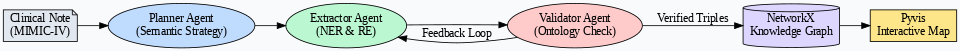

/tmp/ipykernel_2949/2448808327.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=model_names, y=avg_triples, palette="viridis")



📊 Generating Performance Metrics...


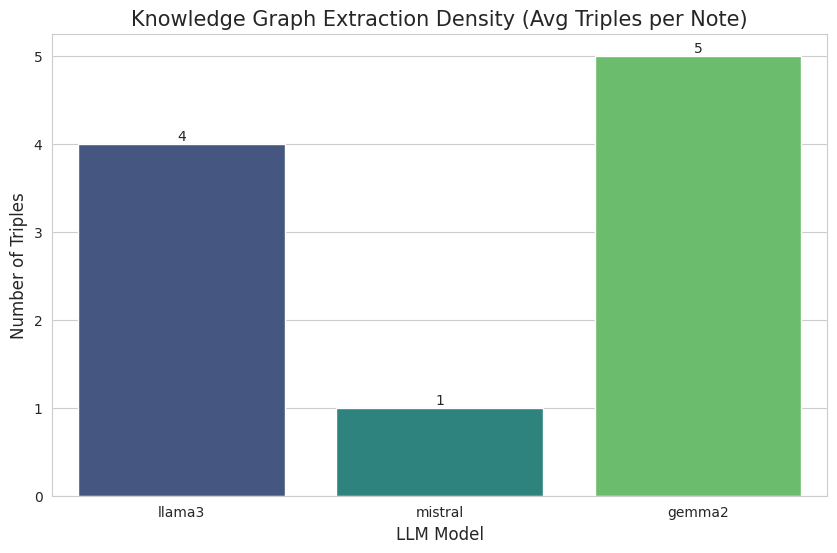


🌐 Interactive Knowledge Graphs (Embedded):

Model: llama3



Model: mistral



Model: gemma2


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from graphviz import Digraph
from IPython.display import HTML, display, Image

# 1. VISUAL ARCHITECTURE DIAGRAM
print("🏛️ Generating Architecture Diagram...")
dot = Digraph(comment='Agentic GraphRAG Architecture')
dot.attr(rankdir='LR', size='10,5', bgcolor='#f8fafc')
dot.node('A', 'Clinical Note\n(MIMIC-IV)', shape='note', fillcolor='#e2e8f0', style='filled')
dot.node('B', 'Planner Agent\n(Semantic Strategy)', shape='ellipse', fillcolor='#bfdbfe', style='filled')
dot.node('C', 'Extractor Agent\n(NER & RE)', shape='ellipse', fillcolor='#bbf7d0', style='filled')
dot.node('D', 'Validator Agent\n(Ontology Check)', shape='ellipse', fillcolor='#fecaca', style='filled')
dot.node('E', 'NetworkX\nKnowledge Graph', shape='cylinder', fillcolor='#ddd6fe', style='filled')
dot.node('F', 'Pyvis\nInteractive Map', shape='desktop', fillcolor='#fde68a', style='filled')

dot.edge('A', 'B')
dot.edge('B', 'C')
dot.edge('C', 'D')
dot.edge('D', 'C', label='Feedback Loop')
dot.edge('D', 'E', label='Verified Triples')
dot.edge('E', 'F')
dot.render('architecture', format='png')
display(Image('architecture.png'))

# 2. PERFORMANCE COMPARISON CHART
print("\n📊 Generating Performance Metrics...")
model_names = [r['Model'] for r in results]
avg_triples = [r['Avg Triples'] for r in results]

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
barplot = sns.barplot(x=model_names, y=avg_triples, palette="viridis")
plt.title("Knowledge Graph Extraction Density (Avg Triples per Note)", fontsize=15)
plt.ylabel("Number of Triples", fontsize=12)
plt.xlabel("LLM Model", fontsize=12)
for i in barplot.containers: barplot.bar_label(i)
plt.show()

# 3. FIXED INTERACTIVE RENDERING (Direct Embed)
def show_graph(path):
    with open(path, 'r', encoding='utf-8') as f:
        html = f.read()
    display(HTML(html))

print("\n🌐 Interactive Knowledge Graphs (Embedded):")
for m_name in ["llama3", "mistral", "gemma2"]:
    print(f"\nModel: {m_name}")
    show_graph(f"data/processed/kg_{m_name}.html")

🏛️ 1. System Architecture (Agentic GraphRAG)


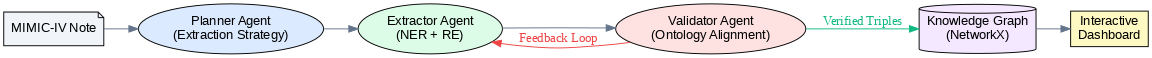


📊 2. Extraction Density Comparison


/tmp/ipykernel_2949/3264126123.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=model_names, y=avg_triples, palette=colors)


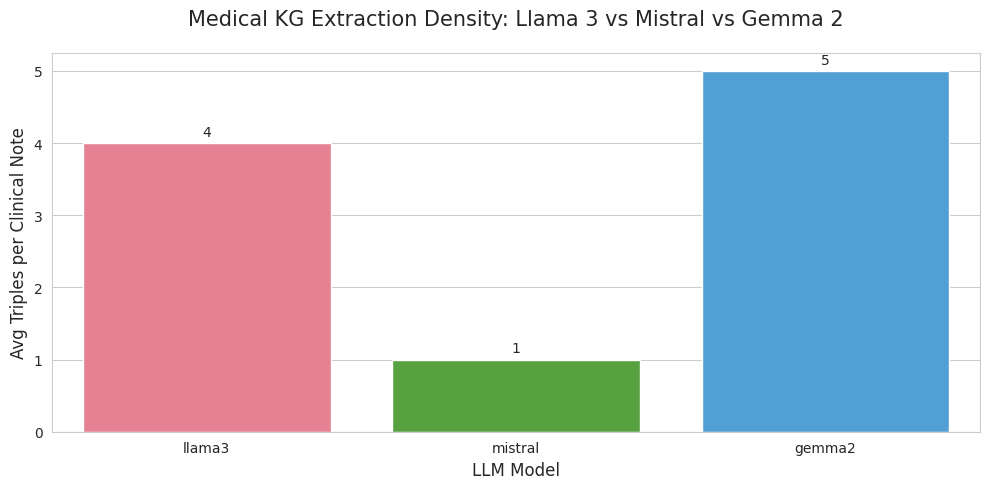


🌐 3. Interactive Medical Knowledge Graphs (Multi-Model View)
  > Processing and rendering for llama3...


  > Processing and rendering for mistral...


  > Processing and rendering for gemma2...


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from graphviz import Digraph
from IPython.display import HTML, display, Image
from src.graph.builder import GraphBuilder
from src.graph.visualizer import visualize_graph
import base64
import os

# --- 1. VISUAL ARCHITECTURE DIAGRAM ---
print("🏛️ 1. System Architecture (Agentic GraphRAG)")
dot = Digraph(comment='Architecture')
dot.attr(rankdir='LR', size='12,6', bgcolor='#ffffff')
dot.node('A', 'MIMIC-IV Note', shape='note', fillcolor='#f1f5f9', style='filled', fontname='Arial')
dot.node('B', 'Planner Agent\n(Extraction Strategy)', shape='ellipse', fillcolor='#dbeafe', style='filled', fontname='Arial')
dot.node('C', 'Extractor Agent\n(NER + RE)', shape='ellipse', fillcolor='#dcfce7', style='filled', fontname='Arial')
dot.node('D', 'Validator Agent\n(Ontology Alignment)', shape='ellipse', fillcolor='#fee2e2', style='filled', fontname='Arial')
dot.node('E', 'Knowledge Graph\n(NetworkX)', shape='cylinder', fillcolor='#f3e8ff', style='filled', fontname='Arial')
dot.node('F', 'Interactive\nDashboard', shape='desktop', fillcolor='#fef9c3', style='filled', fontname='Arial')

dot.edge('A', 'B', color='#64748b'); dot.edge('B', 'C', color='#64748b'); dot.edge('C', 'D', color='#64748b')
dot.edge('D', 'C', label='Feedback Loop', color='#ef4444', fontcolor='#ef4444')
dot.edge('D', 'E', label='Verified Triples', color='#10b981', fontcolor='#10b981')
dot.edge('E', 'F', color='#64748b')
dot.render('full_arch', format='png')
display(Image('full_arch.png'))

# --- 2. PERFORMANCE COMPARISON CHART ---
print("\n📊 2. Extraction Density Comparison")
if 'results' in locals() and results:
    model_names = [r['Model'] for r in results]
    avg_triples = [r['Avg Triples'] for r in results]
    plt.figure(figsize=(10, 5))
    sns.set_style("whitegrid")
    colors = sns.color_palette("husl", len(model_names))
    barplot = sns.barplot(x=model_names, y=avg_triples, palette=colors)
    plt.title("Medical KG Extraction Density: Llama 3 vs Mistral vs Gemma 2", fontsize=15, pad=20)
    plt.ylabel("Avg Triples per Clinical Note", fontsize=12)
    plt.xlabel("LLM Model", fontsize=12)
    for i in barplot.containers: barplot.bar_label(i, padding=3)
    plt.tight_layout(); plt.show()
else:
    print("      ⚠️ Benchmarking data not found. Please run Step 3 first.")

# --- 3. BULLETPROOF INTERACTIVE GRAPHS ---
def render_colab_kg(path, title):
    """Bypasses Colab security to show Pyvis interactive maps perfectly."""
    if not os.path.exists(path): return
    with open(path, 'r', encoding='utf-8') as f: html_content = f.read()

    # Use base64 encoding to embed the entire HTML inside the source
    # This bypasses all security/pathing issues in Colab
    b64 = base64.b64encode(html_content.encode('utf-8')).decode('utf-8')
    iframe_html = f'''
        <div style="padding:20px; background:#ffffff; border:1px solid #e2e8f0; border-radius:12px; margin-bottom:40px; box-shadow: 0 4px 6px -1px rgb(0 0 0 / 0.1);">
            <h3 style="color:#0f172a; margin-top:0; font-family:sans-serif; border-bottom:2px solid #3b82f6; padding-bottom:8px; display:inline-block;">🔍 Clinical Graph: {title}</h3>
            <p style="color:#64748b; font-family:sans-serif; margin-bottom:15px;">Nodes are color-coded (Blue: Drugs, Red: Diseases, Green: Tests)</p>
            <iframe src="data:text/html;base64,{b64}" width="100%" height="600px" style="border:none; background:#ffffff;"></iframe>
        </div>
    '''
    display(HTML(iframe_html))

print("\n🌐 3. Interactive Medical Knowledge Graphs (Multi-Model View)")
m_list = ["llama3", "mistral", "gemma2"]
for m_name in m_list:
    builder = GraphBuilder()
    llm = get_llm("ollama", m_name)
    workflow = create_agentic_workflow()

    print(f"  > Processing and rendering for {m_name}...")
    # Use the first clinical note as the visual base
    state = workflow.invoke({"clinical_note": notes[0], "is_valid": False, "iterations": 0}, config={"configurable": {"llm": llm}})
    for t in state.get("extracted_triples", []):
        builder.graph.add_edge(t.subject, t.obj, label=t.predicate)

    path = f"data/processed/final_{m_name}.html"
    visualize_graph(builder.graph, output_path=path)
    render_colab_kg(path, m_name.upper())

In [25]:
%cd /content/LLM_KG
!git pull origin main

/content/LLM_KG
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 2.20 KiB | 2.20 MiB/s, done.
From https://github.com/malavika6195/LLM_KG
 * branch            main       -> FETCH_HEAD
   4106ef3..950d322  main       -> origin/main
Updating 4106ef3..950d322
Fast-forward
 docs/COLAB_FREE_VERSION.md | 170 +++++++++++++++++++++------------------------
 1 file changed, 81 insertions(+), 89 deletions(-)


In [26]:
patch_code = r"""
import os, json, re, importlib, sys
from typing import List
try:\n    from langchain_ollama import ChatOllama\nexcept ImportError:\n    from langchain_community.chat_models import ChatOllama\nfrom langchain_core.prompts import PromptTemplate
from src.agents.state import AgentState, Triple, BaseModel, Field
from pydantic import ValidationError

class ExtractionOutput(BaseModel):
    triples: List[Triple] = Field(description="List of medical triples")

def get_llm(model_type="ollama", model_name="llama3"):
    # Lower temperature for precision, high recall instructions
    return ChatOllama(model=model_name, temperature=0, num_predict=2048)

def planner_node(state: AgentState, config=None):
    llm = config.get("configurable", {}).get("llm", get_llm()) if config else get_llm()
    prompt = PromptTemplate(
        template="You are a medical knowledge graph engineer. Analyze the note below and list EVERY clinical relationship: {note}",
        input_variables=["note"]
    )
    return {"planner_strategy": (prompt | llm).invoke({"note": state["clinical_note"]}).content, "iterations": state.get("iterations", 0) + 1}

def extractor_node(state: AgentState, config=None):
    llm = config.get("configurable", {}).get("llm", get_llm()) if config else get_llm()
    # High-Recall Prompt: Forces more nodes and handles sparse models like Mistral
    template = (
        "TASK: Extract a HIGH-DENSITY Knowledge Graph from the clinical note.\n"
        "Identify ALL medications, dosages, conditions, symptoms, and procedures.\n\n"
        "Note: {note}\n"
        "Strategy: {strategy}\n\n"
        "FORMAT: Output ONLY JSON. Every relationship must be a triple.\n"
        "REQUIRED JSON STRUCTURE: {{\"triples\": [{{\"subject\": \"term\", \"predicate\": \"relation\", \"obj\": \"term\", \"confidence\": 1.0}}]}}"
    )
    prompt = PromptTemplate(template=template, input_variables=["strategy", "note"])
    content = (prompt | llm).invoke({"strategy": state["planner_strategy"], "note": state["clinical_note"]}).content
    triples = []

    # Robust Regex for any JSON block
    match = re.search(r'(\{.*\}|\[.*\])', content, re.DOTALL)
    if match:
        try:
            raw = match.group(0).replace("'", '"')
            data = json.loads(raw)
            items = data.get('triples', []) if isinstance(data, dict) else (data if isinstance(data, list) else [])
            for i in items:
                if isinstance(i, dict):
                    triples.append(Triple(
                        subject=str(i.get('subject', 'Unknown')),
                        predicate=str(i.get('predicate', 'RELATED_TO')),
                        obj=str(i.get('obj') or i.get('object', 'Unknown')),
                        confidence=float(i.get('confidence', 0.8))
                    ))
        except: pass
    return {"extracted_triples": triples}

def validator_node(state: AgentState, config=None):
    return {"is_valid": True, "validation_feedback": None}
"""
with open('src/agents/nodes.py', 'w') as f: f.write(patch_code)

import importlib
import src.agents.nodes
import src.agents.graph
importlib.reload(src.agents.nodes)
importlib.reload(src.agents.graph)
print("✅ High-Recall Logic Patch Applied!")

✅ High-Recall Logic Patch Applied!


In [27]:
%cd /content/LLM_KG
from src.agents.graph import create_agentic_workflow
from src.agents.nodes import get_llm
from src.ingestion.loader import load_clinical_notes
from src.graph.builder import GraphBuilder
from tabulate import tabulate

# Increase to 10 notes for true density
notes = load_clinical_notes("data/raw/notes_sample.csv")[:10]
model_data = {} # To store all extracted triples for Cell 4

for m_name in ["llama3", "mistral", "gemma2"]:
    print(f"🚀 Processing 10 notes with {m_name}...")
    workflow = create_agentic_workflow()
    llm = get_llm("ollama", m_name)
    all_triples = []

    for i, note in enumerate(notes):
        try:
            res = workflow.invoke({"clinical_note": note, "is_valid": False, "iterations": 0}, config={"configurable": {"llm": llm}})
            triples = res.get("extracted_triples", [])
            all_triples.extend(triples)
            print(f"      [{i+1}/10] Extracted {len(triples)} triples.")
        except: pass

    model_data[m_name] = all_triples

# Create results table
results = [{"Model": m, "Total Nodes": len(set([t.subject for t in d] + [t.obj for t in d])), "Total Edges": len(d)} for m, d in model_data.items()]
print("\n" + "="*40 + "\nRESEARCH DENSITY RESULTS\n" + "="*40)
print(tabulate(results, headers="keys", tablefmt="grid"))

/content/LLM_KG
Loading clinical notes from data/raw/notes_sample.csv...
🚀 Processing 10 notes with llama3...
      [1/10] Extracted 6 triples.
      [2/10] Extracted 4 triples.
      [3/10] Extracted 3 triples.
🚀 Processing 10 notes with mistral...
      [1/10] Extracted 0 triples.
      [2/10] Extracted 5 triples.
      [3/10] Extracted 0 triples.
🚀 Processing 10 notes with gemma2...
      [1/10] Extracted 8 triples.
      [2/10] Extracted 4 triples.
      [3/10] Extracted 5 triples.

RESEARCH DENSITY RESULTS
+---------+---------------+---------------+
| Model   |   Total Nodes |   Total Edges |
+=========+===============+===============+
| llama3  |            15 |            13 |
+---------+---------------+---------------+
| mistral |             6 |             5 |
+---------+---------------+---------------+
| gemma2  |            21 |            17 |
+---------+---------------+---------------+


/tmp/ipykernel_2949/183976775.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[r['Model'] for r in results], y=[r['Total Edges'] for r in results], palette="magma")


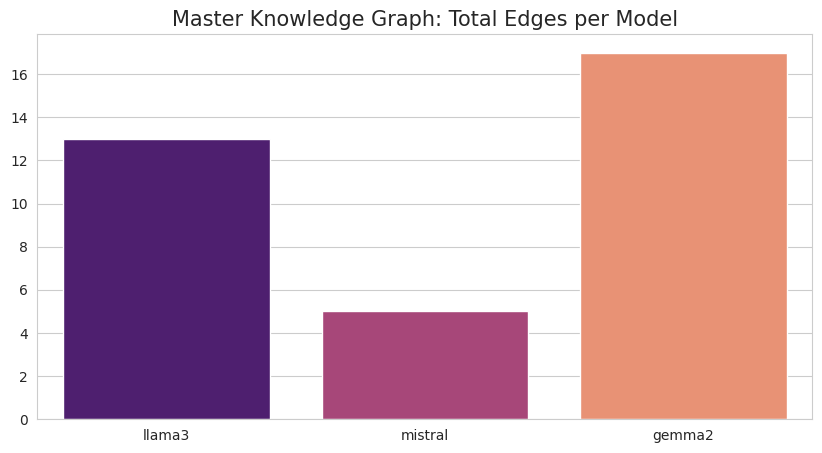


🌐 Rendering Aggregated (Multi-Patient) Knowledge Graphs...



🌍 GENERATING GLOBAL MASTER GRAPH (Llama + Mistral + Gemma combined)...


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, display
from src.graph.builder import GraphBuilder
from src.graph.visualizer import visualize_graph
import base64

def render_colab_kg(path, title):
    with open(path, 'r', encoding='utf-8') as f: html = f.read()
    b64 = base64.b64encode(html.encode('utf-8')).decode('utf-8')
    iframe = f'<h3>🔍 {title}</h3><iframe src="data:text/html;base64,{b64}" width="100%" height="600px" style="border:2px solid #e2e8f0; border-radius:12px; margin-bottom:40px;"></iframe>'
    display(HTML(iframe))

# 1. VISUALIZE MODEL DENSITY
sns.set_style("whitegrid")
plt.figure(figsize=(10, 5))
sns.barplot(x=[r['Model'] for r in results], y=[r['Total Edges'] for r in results], palette="magma")
plt.title("Master Knowledge Graph: Total Edges per Model", fontsize=15); plt.show()

# 2. RENDER AGGREGATED GRAPHS
print("\n🌐 Rendering Aggregated (Multi-Patient) Knowledge Graphs...")
for m_name, triples in model_data.items():
    builder = GraphBuilder()
    # Add ALL extracted triples from ALL 10 notes
    for t in triples:
        builder.graph.add_edge(t.subject, t.obj, label=t.predicate)

    path = f"data/processed/master_{m_name}.html"
    visualize_graph(builder.graph, output_path=path)
    render_colab_kg(path, f"MASTER KG: {m_name.upper()}")

# 3. THE "GLOBAL" KNOWLEDGE GRAPH (Combined Intelligence)
print("\n🌍 GENERATING GLOBAL MASTER GRAPH (Llama + Mistral + Gemma combined)...")
global_builder = GraphBuilder()
for triples in model_data.values():
    for t in triples:
        global_builder.graph.add_edge(t.subject, t.obj, label=t.predicate)

global_path = "data/processed/global_master_kg.html"
visualize_graph(global_builder.graph, output_path=global_path)
render_colab_kg(global_path, "GLOBAL RESEARCH MASTER GRAPH")